# Notebook 03 : ML - Prédiction de Salaire

**Projet :** AI Data Job Market - Prédiction de Salaire  
**Fichier source :** `data/processed/AI_Job_Market_Dataset_Cleaned.csv`  
**Fichier produit :** `models/model_salary.pkl`  

---
### Étapes de ce notebook
| # | Étape | Description |
|---|---|---|
| 1 | Importation | Bibliothèques et dataset nettoyé |
| 2 | Séparation X / y | Variables explicatives vs variable cible |
| 3 | Split train / test | 80% apprentissage, 20% évaluation |
| 4 | Normalisation | StandardScaler sur les colonnes numériques continues |
| 5 | mdl 1 | Régression Linéaire --> meilleur modèle |
| 6 | mdl 2 | Arbre de Décision |
| 7 | mdl 3 | Random Forest |
| 8 | Comparaison | Tableau récapitulatif des 3 modèles |
| 9 | Importance des variables | Quelles variables influencent le plus le salary ? |
| 10 | Sauvegarde | Export du meilleur modèle pour l'interface |


### Régression ou Classification ?

Il existe deux grands types de problèmes ML :

| Type | Ce qu'on prédit | Exemple |
|---|---|---|
| **régression** | un nb continu | prédire un salaire : 95 000, 120 000, 145 000... |
| **classification** | une catégorie | prédire si un email est spam ou non |

**notre problème = régression**, car `salary` est un nb continu.  
on ne cherche pas à dire "ce poste est bien payé" (catégorie),  
mais à prédire **le montant exact** du salaire

## étape 1 : importation des biblios

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

# scikit learn : biblio principale pour le m.l. en Python
from sklearn.model_selection    import train_test_split
from sklearn.preprocessing      import StandardScaler
from sklearn.linear_model       import LinearRegression
from sklearn.tree               import DecisionTreeRegressor
from sklearn.ensemble           import RandomForestRegressor
from sklearn.metrics            import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

print('biblios importées avec succès!')

biblios importées avec succès!


## étape 2 : chargement du dataset et séparation X / y

### qu'est-ce que X et y ?

en ML, on sépare toujours les données en 2 parties :

```
X  =  toutes les colonnes  SAUF  salary
       => ce sont les "indices" qu'on donne au modèle
       => ex : job_title, years_experience, skills_ml...

y  =  uniquement la colonne  salary
       => c'est ce qu'on veut que le modèle apprenne à prédire
```

In [2]:
BASE_DIR   = os.path.dirname(os.path.abspath('__file__'))
CLEAN_PATH = os.path.join(BASE_DIR, '..', 'data', 'processed','AI_Job_Market_Dataset_Cleaned.csv')
MODEL_DIR  = os.path.join(BASE_DIR, '..', 'models')
FIG_DIR    = os.path.join(BASE_DIR, '..', 'figures')
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(FIG_DIR,   exist_ok=True)

df = pd.read_csv(CLEAN_PATH)
print(f'Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes')

# --> Séparation X / y 
X = df.drop(columns=['salary'])   # toutes les colonnes sauf salary
y = df['salary']                  # uniquement salary

print(f'\nX (variables explicatives) : {X.shape}')
print(f'y (variable cible)         : {y.shape}')
print(f'\nColonnes de X :')
print(X.columns.tolist())

Dataset chargé : 10341 lignes × 34 colonnes

X (variables explicatives) : (10341, 33)
y (variable cible)         : (10341,)

Colonnes de X :
['years_experience', 'skills_python', 'skills_sql', 'skills_ml', 'skills_deep_learning', 'skills_cloud', 'job_posting_month', 'job_posting_year', 'hiring_urgency', 'job_openings', 'total_skills', 'job_title_business analyst', 'job_title_data analyst', 'job_title_data engineer', 'job_title_data scientist', 'job_title_machine learning engineer', 'company_size_medium', 'company_size_small', 'company_industry_education', 'company_industry_finance', 'company_industry_healthcare', 'company_industry_retail', 'company_industry_technology', 'country_canada', 'country_germany', 'country_india', 'country_singapore', 'country_uk', 'country_usa', 'remote_type_onsite', 'remote_type_remote', 'education_level_master', 'education_level_phd']


## étape 3 : séparation train / test

### pourquoi diviser les données en 2 groupes ?

Si on entraîne le mdl sur **toutes** les données, puis qu'on le teste sur ces **memes** données,  
le mdl aura "mémorisé" les réponses , comme un élève qui révise exactement les memes exercices  
que ceux de l'examen. Le résultat paraît excellent mais le modèle est inutile en réalité.

**sol :** On cache 20% des données au modèle pendant l'entraînement.  
On les utilise uniquement à la fin pour évaluer la vraie performance.

Dataset complet (10 341 lignes) : 80% train (8 272) , 20% test (2 069)

**`random_state=42`** : garantit que la division est toujours la meme à chaque exécution  
(sinon les résultats changeraient à chaque fois).

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% pour le test
    random_state=42     # résultats reproductibles
)

print('Tailles après split :')
print(f'  X_train : {X_train.shape[0]} lignes  ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'  X_test  : {X_test.shape[0]} lignes  ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'  y_train : {y_train.shape[0]} valeurs')
print(f'  y_test  : {y_test.shape[0]} valeurs')

Tailles après split :
  X_train : 8272 lignes  (80%)
  X_test  : 2069 lignes  (20%)
  y_train : 8272 valeurs
  y_test  : 2069 valeurs


## étape 4 : normalisation des vars numériques continues

In [4]:

cols_a_normaliser = ['years_experience', 'job_openings',
                     'job_posting_month', 'job_posting_year', 'total_skills']

scaler = StandardScaler()

#on crée des copies pour ne pas modifier les originaux
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

#fit_transform sur le train : apprend l'échelle ET transforme
X_train_scaled[cols_a_normaliser] = scaler.fit_transform(X_train[cols_a_normaliser])

#transform seulement sur le test : applique l'échelle apprise du train
X_test_scaled[cols_a_normaliser]  = scaler.transform(X_test[cols_a_normaliser])

print('normalisation terminée')
print('\nvérification —> moyennes après normalisation (doivent être ≈ 0 sur le train) :')
print(X_train_scaled[cols_a_normaliser].mean().round(4))

normalisation terminée

vérification —> moyennes après normalisation (doivent être ≈ 0 sur le train) :
years_experience    -0.0
job_openings         0.0
job_posting_month    0.0
job_posting_year     0.0
total_skills        -0.0
dtype: float64


## étape 5 : Modèle 1 : R. L.

### Comment ça fonctionne ?

La R. L. cherche une éq de droite qui relie les variables au salary :
salary = (a₁ × years_experience)
       + (a₂ × skills_ml)
       + (a₃ × job_title_ml_engineer)
       + ... 
       + b

Chaque coefficient `a` représente l'impact de chaque variable sur le salary!

**avantages :** Simple, rapide, facile à interpréter  
**inconvénients :** Ne capte pas les relations non-linéaires (courbes, interactions complexes)

**Utilise les données normalisées** car la RL est sensible aux échelles!!

--- Regression Linéaire ---
  MAE  :     18,353 USD  (erreur moyenne de prédiction)
  RMSE :     21,549 USD
  R^2  :     0.5232      (le modèle explique 52.3% des variations)




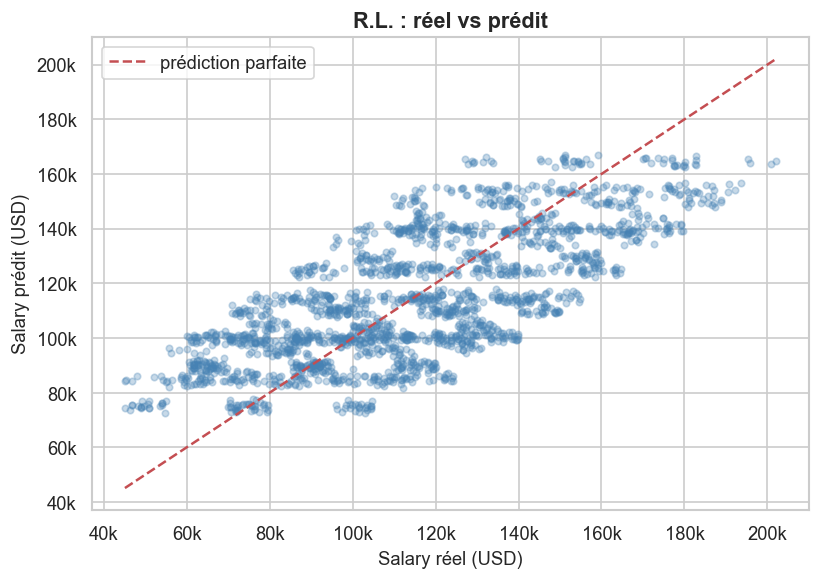

In [5]:
#entrainement 
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)   # le mdl apprend sur les données d'entraînement
#prédiction 
y_pred_lr = lr.predict(X_test_scaled)  # on prédit sur les données de test

#evaluation 
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print('--- Regression Linéaire ---')
print(f'  MAE  : {mae_lr:>10,.0f} USD  (erreur moyenne de prédiction)')
print(f'  RMSE : {rmse_lr:>10,.0f} USD')
#veulliez changer R^2 en R²: Alt+253
print(f'  R^2  : {r2_lr:>10.4f}      (le modèle explique {r2_lr*100:.1f}% des variations)\n\n')

#visualisation : réel vs prédit 
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test, y_pred_lr, alpha=0.3, s=15, color='steelblue')
lims = [y_test.min(), y_test.max()]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='prédiction parfaite')
ax.set_xlabel('Salary réel (USD)', fontsize=11)
ax.set_ylabel('Salary prédit (USD)', fontsize=11)
ax.set_title('R.L. : réel vs prédit', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}k'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}k'))
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'ml_g1_lr_reel_vs_predit.png'), dpi=150, bbox_inches='tight')
plt.show()

## étape 6 : mdl 2 :arbre de décision

### comment ça fonctionne ?

Un Arbre de Décision pose une série de **questions** sur les données pour arriver  
à une prédiction, exactement comme le jeu "Qui est-ce ?" :

```
Est-ce que job_title = ML Engineer ?
         OUI => years_experience > 8 ?
                   OUI => salary prédit = 165 000
                   NON => salary prédit = 140 000
        NON => skills_ml = 1 ?
                    OUI => salary prédit = 120 000
                    NON => salary prédit = 90 000
```

**Paramètre `max_depth=8`** : limite la profondeur de l'arbre.  
Sans limite, l'arbre mémoriserait chaque ligne — il serait parfait sur le train  
mais horrible sur le test. C'est ce qu'on appelle le **surapprentissage (overfitting)**.

**avantages :** Facile à visualiser et interpréter, pas besoin de normalisation  
**inconvénients :** tendency au surapprentissage si `max_depth` trop grand

===arbre de Décision ===
  MAE  :     19,135 USD
  RMSE :     22,646 USD
  R^2   :     0.4734      (le modèle explique 47.3% des variations)


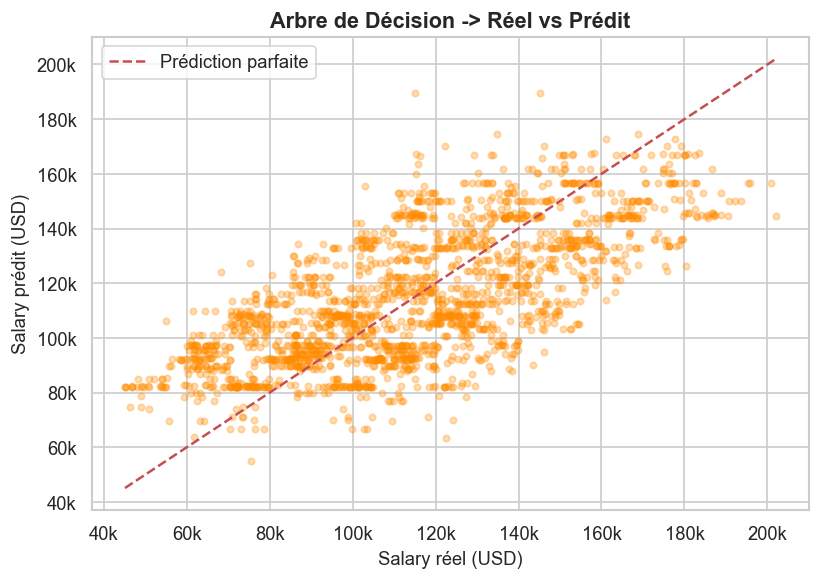

In [6]:
# arbre de décision : utilise les données NON normalisées
dt = DecisionTreeRegressor(max_depth=8, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

mae_dt  = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt   = r2_score(y_test, y_pred_dt)

print('===arbre de Décision ===')
print(f'  MAE  : {mae_dt:>10,.0f} USD')
print(f'  RMSE : {rmse_dt:>10,.0f} USD')
print(f'  R^2   : {r2_dt:>10.4f}      (le modèle explique {r2_dt*100:.1f}% des variations)')

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test, y_pred_dt, alpha=0.3, s=15, color='darkorange')
lims = [y_test.min(), y_test.max()]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Prédiction parfaite')
ax.set_xlabel('Salary réel (USD)', fontsize=11)
ax.set_ylabel('Salary prédit (USD)', fontsize=11)
ax.set_title('Arbre de Décision -> Réel vs Prédit', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}k'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}k'))
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'ml_g2_dt_reel_vs_predit.png'), dpi=150, bbox_inches='tight')
plt.show()

## Étape 7 : Modèle 3 : Random Forest  

### Comment ça fonctionne ?

Un **Random Forest** (Forêt Aléatoire) est un ensemble de nombreux Arbres de Décision.  
Chaque arbre apprend sur une portion légèrement différente des données.  
La prédiction finale = **moyenne** des prédictions de tous les arbres.

```

Paramètres importants :
- `n_estimators=100` : nombre d'arbres dans la forêt
- `maxdepth=10` : profondeur max de chaque arbre (évite le surapprentissage)
- `n_jobs=-1` : utilise tous les processeurs disponibles pour aller plus vite
```

entrainement du Random Forest (peut prendre quelques secondes)...
entrainement terminé

=== Random Forest ===
  MAE  :     18,641 USD
  RMSE :     22,044 USD
  R^2  :     0.5010      (le modèle explique 50.1% des variations)


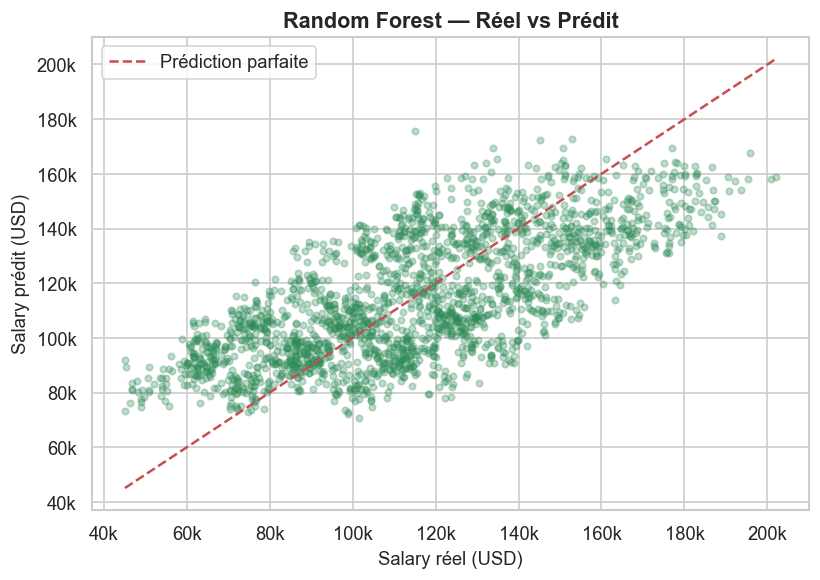

In [7]:

rf = RandomForestRegressor(
    n_estimators=100,   # 100 arbres dans la foret
    max_depth=10,       # pfd max de chaque arbre
    random_state=42,
    n_jobs=-1           # utilise tous les cœurs du processeur
)

print('entrainement du Random Forest (peut prendre quelques secondes)...')
rf.fit(X_train, y_train)
print('entrainement terminé')

y_pred_rf = rf.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print('\n=== Random Forest ===')
print(f'  MAE  : {mae_rf:>10,.0f} USD')
print(f'  RMSE : {rmse_rf:>10,.0f} USD')
print(f'  R^2  : {r2_rf:>10.4f}      (le modèle explique {r2_rf*100:.1f}% des variations)')

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test, y_pred_rf, alpha=0.3, s=15, color='seagreen')
lims = [y_test.min(), y_test.max()]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Prédiction parfaite')
ax.set_xlabel('Salary réel (USD)', fontsize=11)
ax.set_ylabel('Salary prédit (USD)', fontsize=11)
ax.set_title('Random Forest — Réel vs Prédit', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}k'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}k'))
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'ml_g3_rf_reel_vs_predit.png'), dpi=150, bbox_inches='tight')
plt.show()

## Étape 8 : Comparaison des 3 modèles

On rassemble les résultats dans un tableau pour choisir le meilleur modèle.

=== tableau comparatif des modeles ===
             Modele MAE (USD) RMSE (USD)     R2
Regression Lineaire    18,353     21,549 0.5232
  Arbre de Decision    19,135     22,646 0.4734
      Random Forest    18,641     22,044 0.5010


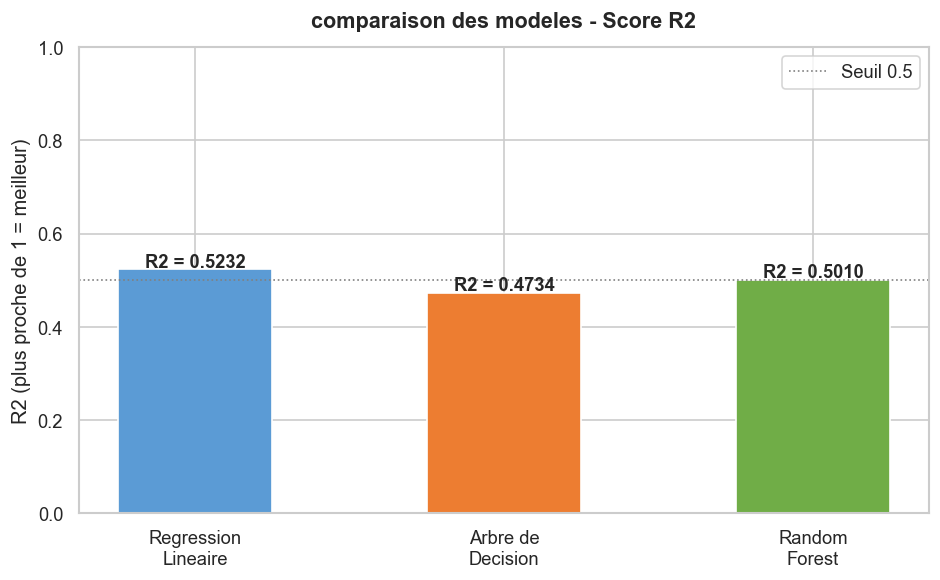


meilleur modele : Regression Lineaire
   R2 = 0.5232 -> explique 52.3% des variations de salary
   MAE = 18,353 USD -> erreur moyenne de prediction


In [8]:
resultats = pd.DataFrame({
    'Modele' : ['Regression Lineaire', 'Arbre de Decision', 'Random Forest'],
    'MAE (USD)' : [mae_lr, mae_dt, mae_rf],
    'RMSE (USD)': [rmse_lr, rmse_dt, rmse_rf],
    'R2'        : [r2_lr, r2_dt, r2_rf]
})

resultats['MAE (USD)']  = resultats['MAE (USD)'].apply(lambda x: f'{x:,.0f}')
resultats['RMSE (USD)'] = resultats['RMSE (USD)'].apply(lambda x: f'{x:,.0f}')
resultats['R2']         = resultats['R2'].apply(lambda x: f'{x:.4f}')

print('=== tableau comparatif des modeles ===')
print(resultats.to_string(index=False))

noms    = ['Regression\nLineaire', 'Arbre de\nDecision', 'Random\nForest']
r2_vals = [r2_lr, r2_dt, r2_rf]
couleurs = ['#5b9bd5', '#ed7d31', '#70ad47']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(noms, r2_vals, color=couleurs, edgecolor='white', width=0.5)
for bar, val in zip(bars, r2_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
            f'R2 = {val:.4f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_ylabel('R2 (plus proche de 1 = meilleur)', fontsize=12)
ax.set_title('comparaison des modeles - Score R2', fontsize=13, fontweight='bold', pad=12)
ax.axhline(y=0.5, color='gray', linestyle=':', linewidth=1, label='Seuil 0.5')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'ml_g4_comparaison_modeles.png'), dpi=150, bbox_inches='tight')
plt.show()

meilleur_r2 = max(r2_lr, r2_dt, r2_rf)
if meilleur_r2 == r2_lr:
    print('\nmeilleur modele : Regression Lineaire')
    print(f'   R2 = {r2_lr:.4f} -> explique {r2_lr*100:.1f}% des variations de salary')
    print(f'   MAE = {mae_lr:,.0f} USD -> erreur moyenne de prediction')
elif meilleur_r2 == r2_dt:
    print('\nmeilleur modele : Arbre de Decision')
    print(f'   R2 = {r2_dt:.4f} -> explique {r2_dt*100:.1f}% des variations de salary')
    print(f'   MAE = {mae_dt:,.0f} USD -> erreur moyenne de prediction')
else:
    print('\nmeilleur modele : Random Forest')
    print(f'   R2 = {r2_rf:.4f} -> explique {r2_rf*100:.1f}% des variations de salary')
    print(f'   MAE = {mae_rf:,.0f} USD -> erreur moyenne de prediction')

## Étape 9 : Importance des variables (Feature Importance)

Le Random Forest permet de savoir quelles variables ont le plus influencé
ses prédictions. C'est une information précieuse pour comprendre le marché

**Interprétation :** Une variable avec importance = 0.20 signifie qu'elle contribue  
à 20% des décisions du modèle pour prédire le salary.

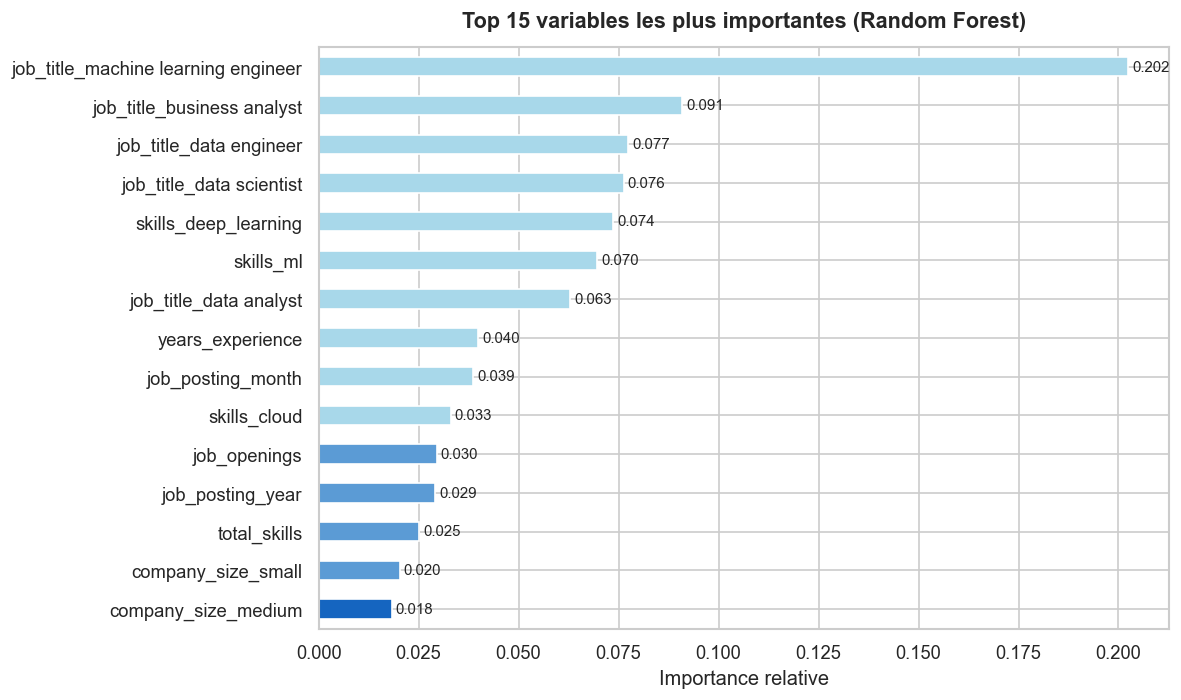

Top 10 variables les plus importantes :
  job_title_machine learning engineer      : 0.2025  (20.2%)
  job_title_business analyst               : 0.0909  (9.1%)
  job_title_data engineer                  : 0.0774  (7.7%)
  job_title_data scientist                 : 0.0763  (7.6%)
  skills_deep_learning                     : 0.0736  (7.4%)
  skills_ml                                : 0.0696  (7.0%)
  job_title_data analyst                   : 0.0629  (6.3%)
  years_experience                         : 0.0400  (4.0%)
  job_posting_month                        : 0.0386  (3.9%)
  skills_cloud                             : 0.0331  (3.3%)


In [9]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#1565c0' if i == 0 else '#5b9bd5' if i < 5 else '#a8d8ea'
          for i in range(len(importances))]
importances.sort_values().plot.barh(ax=ax, color=colors, edgecolor='white')

ax.set_title('Top 15 variables les plus importantes (Random Forest)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Importance relative', fontsize=12)
ax.set_ylabel('')
for i, (val, nom) in enumerate(zip(importances.sort_values(), importances.sort_values().index)):
    ax.text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'ml_g5_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 variables les plus importantes :')
for nom, val in importances.head(10).items():
    print(f'  {nom:<40s} : {val:.4f}  ({val*100:.1f}%)')

## étape 10 : sauvegarde du meilleur mdl

on sauvegarde le meilleur mdl dans un fichier .pkl (format pickle, std Python)
pour pouvoir le réutiliser dans l'interface graphique sans avoir a réentrainer.

le meilleur mdl est determiné automatiquement en comparant les R2 des 3 mdl.
sur cette execution, le meilleur mdl est la Regression Lineaire avec R2 = 0.5232.

on sauvegarde 4 objets ensemble dans un dictionnaire :
1. meilleur_modl => le mdl ayant le R2 le plus élevé parmi les 3
2. scaler => le StandardScaler entraine sur le train. l'interface en aura
   besoin pour normaliser les données saisies par l'utilisateur avant
   de les envoyer au mdl
3. colonnes => la liste exacte des 33 cols dans le bon ordre. l'interface
   doit envoyer exactement les memes cols que celles utilisees pendant
   l'entrainement
4. cols_a_normaliser => la liste des 5 cols à normaliser. l'interface doit
   savoir quelles cols appliquer le scaler

In [10]:
meilleur_r2 = max(r2_lr, r2_dt, r2_rf)
if meilleur_r2 == r2_lr:
    meilleur_modele = lr
    nom_modele = 'Regression Lineaire'
    X_pred = X_test_scaled
elif meilleur_r2 == r2_dt:
    meilleur_modele = dt
    nom_modele = 'Arbre de Decision'
    X_pred = X_test
else:
    meilleur_modele = rf
    nom_modele = 'Random Forest'
    X_pred = X_test

bundle = {
    'model'            : meilleur_modele,
    'scaler'           : scaler,
    'colonnes'         : X.columns.tolist(),
    'cols_a_normaliser': cols_a_normaliser
}

MODEL_PATH = os.path.join(MODEL_DIR, 'model_salary.pkl')
with open(MODEL_PATH, 'wb') as f:
    pickle.dump(bundle, f)

print(f'modele sauvegardé : {nom_modele}')
print(f'chemin : {MODEL_PATH}')

with open(MODEL_PATH, 'rb') as f:
    bundle_test = pickle.load(f)

model_recharge = bundle_test['model']
pred_test = model_recharge.predict(X_pred.head(3))
reel_test = y_test.head(3).values

print('\nverification : 3 premieres predictions apres rechargement :')
for i, (pred, reel) in enumerate(zip(pred_test, reel_test), 1):
    print(f'  ligne {i} : predit = {pred:>10,.0f} USD  |  reel = {reel:>10,.0f} USD  |  ecart = {abs(pred-reel):,.0f} USD')

print('\nmodele rechargé et fonctionnel.')

modele sauvegardé : Regression Lineaire
chemin : C:\Users\Admin\Desktop\ai-job-salary-predictor\notebooks\..\models\model_salary.pkl

verification : 3 premieres predictions apres rechargement :
  ligne 1 : predit =    102,486 USD  |  reel =    100,095 USD  |  ecart = 2,391 USD
  ligne 2 : predit =     75,450 USD  |  reel =    101,204 USD  |  ecart = 25,754 USD
  ligne 3 : predit =    139,239 USD  |  reel =    162,365 USD  |  ecart = 23,126 USD

modele rechargé et fonctionnel.


---
## resume du notebook ML

| etape | action | resultat |
|---|---|---|
| separation X/y | 33 variables explicatives + 1 cible | OK |
| split 80/20 | 8 272 train / 2 069 test | OK |
| normalisation | StandardScaler sur 5 cols continues | OK |
| RL | MAE = 18 353 USD, R2 = 0.5232 | meilleur mdl |
| arbre de decision | MAE = 19 135 USD, R2 = 0.4734 | moins bon |
| random forest | MAE = 18 641 USD, R2 = 0.5010 | moins bon |
| sauvegarde | models/model_salary.pkl | OK |

variables les plus importantes pour predire le salary (selon le random forest) :
1. job_title_machine_learning_engineer (20.2%)
2. job_title_business_analyst (9.1%)
3. job_title_data_engineer (7.7%)
4. job_title_data_scientist (7.6%)
5. skills_deep_learning (7.4%)
6. skills_ml (7.0%)
7. job_title_data_analyst (6.3%)
8. years_experience (4.0%)
9. job_posting_month (3.9%)
10. skills_cloud (3.3%)

etape suivante : interface graphique
l'interface chargera model_salary.pkl et permettra a un utilisateur de saisir
les caracteristiques d'un poste pour obtenir une prediction de salary.